In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import importlib
ROOT = Path().resolve()

sys.path.insert(0, str(ROOT))

# Import cleaning and feature functions
from src.processing import clean_pgcb, clean_weather
from src.features import make_features

In [2]:
pgcb_dataset = pd.read_csv(ROOT / "data/raw/PGCB_date_power_demand.csv")
weather_dataset = pd.read_csv(ROOT / "data/raw/weather_data.csv", skiprows=3)

pgcb_dataset['datetime'] = pd.to_datetime(pgcb_dataset['datetime'])
weather_dataset['time'] = pd.to_datetime(weather_dataset['time'])

pgcb_train_raw = pgcb_dataset[pgcb_dataset['datetime'].dt.year <= 2023].copy()
pgcb_test_raw  = pgcb_dataset[pgcb_dataset['datetime'].dt.year == 2024].copy()

weather_train_raw = weather_dataset[weather_dataset['time'].dt.year <= 2023].copy()
weather_test_raw  = weather_dataset[weather_dataset['time'].dt.year == 2024].copy()

In [3]:
# Clean train and test separately
pgcb_cleaned_train = clean_pgcb(pgcb_train_raw)
pgcb_cleaned_test  = clean_pgcb(pgcb_test_raw)

weather_cleaned_train = clean_weather(weather_train_raw)
weather_cleaned_test  = clean_weather(weather_test_raw)

C:\Users\ggowt\JupyterWorks\IITG.AI_rec_2\src\processing.py:41: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(df['datetime'].min(), df['datetime'].max(), freq='H')
C:\Users\ggowt\JupyterWorks\IITG.AI_rec_2\src\processing.py:41: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(df['datetime'].min(), df['datetime'].max(), freq='H')
C:\Users\ggowt\JupyterWorks\IITG.AI_rec_2\src\processing.py:148: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(df['time'].min(), df['time'].max(), freq='H')
C:\Users\ggowt\JupyterWorks\IITG.AI_rec_2\src\processing.py:148: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(df['time'].min(), df['time'].max(), freq='H')


In [4]:
economics_df = pd.read_csv(ROOT / 'data/processed/economic_cleaned.csv')

In [5]:
year_cols = [str(y) for y in range(2015, 2025)]

economic_cleaned = economics_df.set_index('Indicator Code')[year_cols].T
economic_cleaned.index.name = 'year'
economic_cleaned.index = economic_cleaned.index.astype(int)

# Split into train (<=2023) and test (2024)
econ_train = economic_cleaned[economic_cleaned.index <= 2023].copy()
econ_test  = economic_cleaned[economic_cleaned.index == 2024].copy()

print(f"econ_train years : {econ_train.index.tolist()}")
print(f"econ_test years  : {econ_test.index.tolist()}")

econ_train years : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
econ_test years  : [2024]


In [6]:

# 1. Create features
train_final = make_features(pgcb_cleaned_train, weather_cleaned_train, econ_train)
test_final  = make_features(pgcb_cleaned_test,  weather_cleaned_test,  econ_test)

# 2. Shift target to NEXT hour
train_final['target'] = train_final['demand_mw'].shift(-1)
test_final['target']  = test_final['demand_mw'].shift(-1)

train_final = train_final.dropna(subset=['target']).reset_index(drop=True)
test_final  = test_final.dropna(subset=['target']).reset_index(drop=True)

# 4. Prepare X and y
X_train = train_final.drop(columns=['datetime', 'demand_mw', 'target'])
y_train = train_final['target']

X_test = test_final.drop(columns=['datetime', 'demand_mw', 'target'])
y_test = test_final['target']

print(" Data prepared successfully")
print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")
print(f"NaNs in y_train: {y_train.isna().sum()}")
print(f"NaNs in y_test : {y_test.isna().sum()}")

 Data prepared successfully
Train shape : (76295, 33)
Test shape  : (8783, 33)
NaNs in y_train: 0
NaNs in y_test : 0


In [7]:
train_final.isna().sum()

datetime                  0
demand_mw                 0
gas                       0
liquid_fuel               0
coal                      0
hydro                     0
solar                     0
wind                      0
india_bheramara_hvdc      0
india_tripura             0
hour                      0
dayofweek                 0
month                     0
lag_1h                    1
lag_24h                  24
lag_168h                168
rolling_mean_24h          1
rolling_mean_168h         1
apparent_temperature      0
precipitation             0
dew_point                 0
wind_direction            0
cloud_cover               0
sunshine_duration         0
wind_sin                  0
wind_cos                  0
SP.POP.GROW               0
NV.IND.MANF.ZS            0
EG.ELC.ACCS.ZS            0
SP.POP.TOTL               0
NY.GDP.MKTP.KD.ZG         0
NY.GDP.MKTP.CD            0
NV.IND.MANF.KD.ZG         0
gdp_per_capita            0
econ_growth               0
target              

# Training Model

In [8]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error

print("Starting simple tuning...\n")

best_mape = 100
best_params = None

for n_est in [500, 800]:
    for depth in [7, 8, 9]:
        for lr in [0.03, 0.05]:
            
            model = xgb.XGBRegressor(
                n_estimators=n_est,
                max_depth=depth,
                learning_rate=lr,
                random_state=42
            )
            
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            mape = mean_absolute_percentage_error(y_test, pred) * 100
            
            print(f"n_est={n_est}, depth={depth}, lr={lr}  →  MAPE = {mape:.4f}%")
            
            if mape < best_mape:
                best_mape = mape
                best_params = {'n_estimators': n_est, 'max_depth': depth, 'learning_rate': lr}

print("\nBest MAPE:", round(best_mape, 4), "%")
print("Best Params:", best_params)

Starting simple tuning...

n_est=500, depth=7, lr=0.03  →  MAPE = 3.6526%
n_est=500, depth=7, lr=0.05  →  MAPE = 3.8757%
n_est=500, depth=8, lr=0.03  →  MAPE = 3.5130%
n_est=500, depth=8, lr=0.05  →  MAPE = 3.5752%
n_est=500, depth=9, lr=0.03  →  MAPE = 3.3640%
n_est=500, depth=9, lr=0.05  →  MAPE = 3.4652%
n_est=800, depth=7, lr=0.03  →  MAPE = 3.8771%
n_est=800, depth=7, lr=0.05  →  MAPE = 4.0376%
n_est=800, depth=8, lr=0.03  →  MAPE = 3.6181%
n_est=800, depth=8, lr=0.05  →  MAPE = 3.6024%
n_est=800, depth=9, lr=0.03  →  MAPE = 3.4062%
n_est=800, depth=9, lr=0.05  →  MAPE = 3.4875%

Best MAPE: 3.364 %
Best Params: {'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.03}


In [9]:
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'datetime': test_final['datetime'],
    'actual': y_test,
    'predicted': pred
})

# Save predictions to CSV
results.to_csv(ROOT / "data/processed/predictions.csv", index=False)

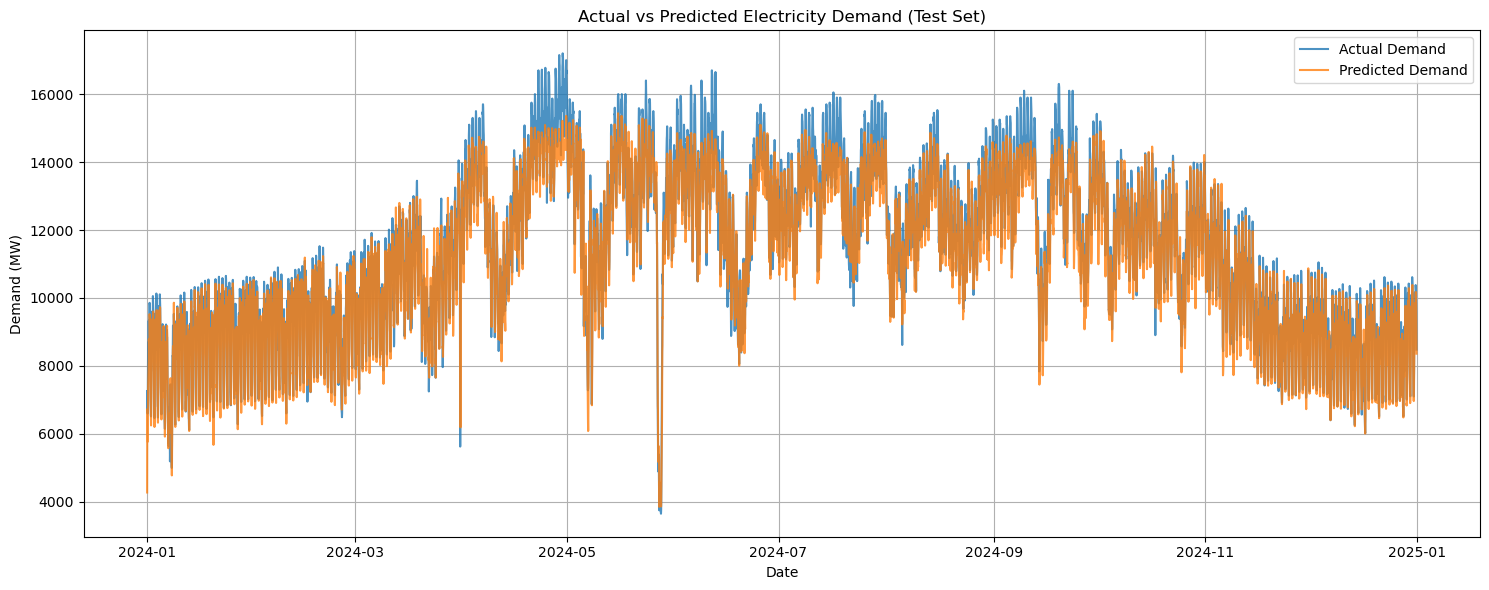

In [10]:
plt.figure(figsize=(15, 6))
plt.plot(results['datetime'], results['actual'], label='Actual Demand', alpha=0.8)
plt.plot(results['datetime'], results['predicted'], label='Predicted Demand', alpha=0.8)
plt.title('Actual vs Predicted Electricity Demand (Test Set)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()